In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.colors as mcolors
import warnings
from scipy.stats import pointbiserialr

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

import optuna
import sys
import shap

from pycaret.classification import setup, compare_models, predict_model, save_model, evaluate_model

import tensorflow as tf
from tensorflow.keras.utils import to_categorical

import warnings
warnings.simplefilter('ignore')

In [2]:
df = pd.read_csv("weatherAUS.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [3]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


# Entrega número 1

## Clusterización de ciudades

In [4]:
# Coordenadas de las ciudades

#locations = df['Location'].unique()
coordenadas = {
    'Albury': (-36.0737, 146.9135),
    'BadgerysCreek': (-33.8833, 150.7333),
    'Cobar': (-31.4958, 145.8386),
    'CoffsHarbour': (-30.2963, 153.1139),
    'Moree': (-29.4628, 149.8419),
    'Newcastle': (-32.9283, 151.7817),
    'NorahHead': (-33.2817, 151.5714),
    'NorfolkIsland': (-29.0408, 167.9547),
    'Penrith': (-33.7511, 150.6942),
    'Richmond': (-33.6000, 150.7500),
    'Sydney': (-33.8688, 151.2093),
    'SydneyAirport': (-33.9461, 151.1772),
    'WaggaWagga': (-35.1082, 147.3598),
    'Williamtown': (-32.8156, 151.8431),
    'Wollongong': (-34.4278, 150.8931),
    'Canberra': (-35.2809, 149.1300),
    'Tuggeranong': (-35.4244, 149.0878),
    'MountGinini': (-35.5297, 148.7731),
    'Ballarat': (-37.5622, 143.8503),
    'Bendigo': (-36.7570, 144.2794),
    'Sale': (-38.1069, 147.0664),
    'MelbourneAirport': (-37.6690, 144.8410),
    'Melbourne': (-37.8136, 144.9631),
    'Mildura': (-34.1872, 142.1386),
    'Nhil': (-36.3319, 141.6503),
    'Portland': (-38.3453, 141.6044),
    'Watsonia': (-37.7111, 145.0831),
    'Dartmoor': (-37.9217, 141.2711),
    'Brisbane': (-27.4698, 153.0251),
    'Cairns': (-16.9186, 145.7781),
    'GoldCoast': (-28.0167, 153.4000),
    'Townsville': (-19.2590, 146.8169),
    'Adelaide': (-34.9285, 138.6007),
    'MountGambier': (-37.8297, 140.7828),
    'Nuriootpa': (-34.4667, 138.9833),
    'Woomera': (-31.1558, 136.8269),
    'Albany': (-35.0269, 117.8842),
    'Witchcliffe': (-34.0278, 115.1006),
    'PearceRAAF': (-31.6678, 116.0150),
    'PerthAirport': (-31.9403, 115.9672),
    'Perth': (-31.9505, 115.8605),
    'SalmonGums': (-32.9833, 121.6333),
    'Walpole': (-34.9778, 116.7333),
    'Hobart': (-42.8821, 147.3272),
    'Launceston': (-41.4332, 147.1441),
    'AliceSprings': (-23.6980, 133.8807),
    'Darwin': (-12.4634, 130.8456),
    'Katherine': (-14.4653, 132.2636),
    'Uluru': (-25.3444, 131.0369)
}

coord_ciudades = pd.DataFrame([
    {'Location': ciudad, 'Latitude': coords[0], 'Longitude': coords[1]}
    for ciudad, coords in coordenadas.items()
])

coord_ciudades.head()

,Location,Latitude,Longitude
0,Albury,-36.0737,146.9135
1,BadgerysCreek,-33.8833,150.7333
2,Cobar,-31.4958,145.8386
3,CoffsHarbour,-30.2963,153.1139
4,Moree,-29.4628,149.8419


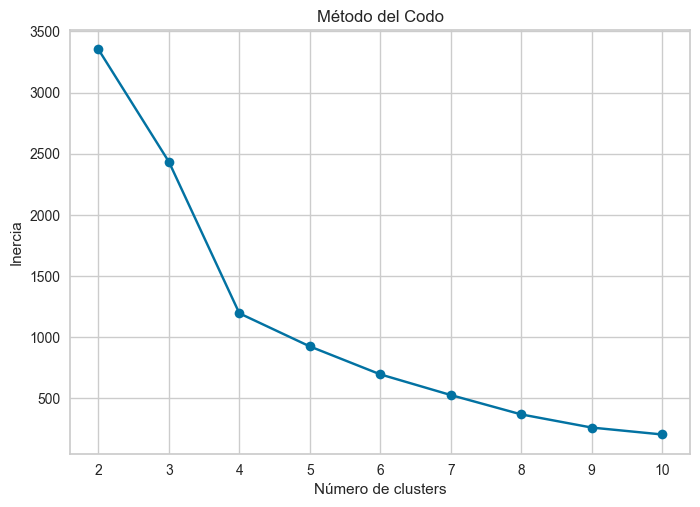

In [5]:
X = coord_ciudades[['Latitude', 'Longitude']].values
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Graficar
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

Se eligieron 4 clusters porque en el gráfico del método del codo la inercia deja de disminuir de forma significativa a partir de ese punto, indicando que agregar más clusters no mejora sustancialmente la agrupación.

In [6]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
coord_ciudades['Region'] = kmeans.fit_predict(X)

unique_regions = coord_ciudades['Region'].unique()
num_colors = len(unique_regions)
color_palette = plt.get_cmap('tab10', num_colors)
region_color_map = {str(region): mcolors.to_hex(color_palette(i)) 
                    for i, region in enumerate(sorted(unique_regions))}

fig = px.scatter(coord_ciudades, 
                 x='Longitude', 
                 y='Latitude', 
                 color='Region',
                 labels={'Longitude': 'Longitud', 
                         'Latitude': 'Latitud',
                         'Region': 'Región'},
                 color_discrete_map=region_color_map,
                 title=f'Clustering con K-means')

fig.update_traces(marker=dict(size=10))
fig.show()

In [7]:
print(coord_ciudades.groupby('Region')['Location'].count())
coord_ciudades.head()

Region
0    19
1     7
2    17
3     6
Name: Location, dtype: int64


,Location,Latitude,Longitude,Region
0,Albury,-36.0737,146.9135,0
1,BadgerysCreek,-33.8833,150.7333,2
2,Cobar,-31.4958,145.8386,0
3,CoffsHarbour,-30.2963,153.1139,2
4,Moree,-29.4628,149.8419,2


In [8]:
df = df.merge(coord_ciudades, on='Location', how='left')
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Latitude,Longitude,Region
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.1,8.0,NaN,16.9,21.8,No,No,-36.0737,146.9135,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1007.8,NaN,NaN,17.2,24.3,No,No,-36.0737,146.9135,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,1008.7,NaN,2.0,21.0,23.2,No,No,-36.0737,146.9135,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,1012.8,NaN,NaN,18.1,26.5,No,No,-36.0737,146.9135,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,1006.0,7.0,8.0,17.8,29.7,No,No,-36.0737,146.9135,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,1020.3,NaN,NaN,10.1,22.4,No,No,-25.3444,131.0369,3
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,1019.1,NaN,NaN,10.9,24.5,No,No,-25.3444,131.0369,3
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,1016.8,NaN,NaN,12.5,26.1,No,No,-25.3444,131.0369,3
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,1016.5,3.0,2.0,15.1,26.0,No,No,-25.3444,131.0369,3


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
warnings.filterwarnings("ignore")

In [10]:
print(df.columns.tolist())

['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'Latitude', 'Longitude', 'Region']


## Análisis descriptivo

**División cruzada train - test**

In [11]:
# Imputamos la variable RainTomorrow antes de dividir el dataset ya que no puede haber nulos en esta variable
# Decidimos esto ya que es la variable a predecir.
df['RainTomorrow_from_next'] = df.groupby('Location')['RainToday'].shift(-1)
df.loc[df['RainTomorrow'].isna(), 'RainTomorrow'] = \
    df.loc[df['RainTomorrow'].isna(), 'RainTomorrow_from_next']
df = df.drop('RainTomorrow_from_next', axis=1)

#Eliminamos las filas que no pudieron ser impuitadas de ninguna forma
print('Fueron borrados', df['RainTomorrow'].isna().sum(), 'datos')
df = df[df['RainTomorrow'].notna()].reset_index(drop=True)

Fueron borrados 3267 datos


In [12]:
# Dividir en X e y
X = df.drop(columns='RainTomorrow')
y = df['RainTomorrow']

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 113754
Test size: 28439


**Visualización de datos** (previo a la imputación)

In [13]:
show = X_train[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
                'Temp3pm']].copy()

show['RainTomorrow'] = y_train.values

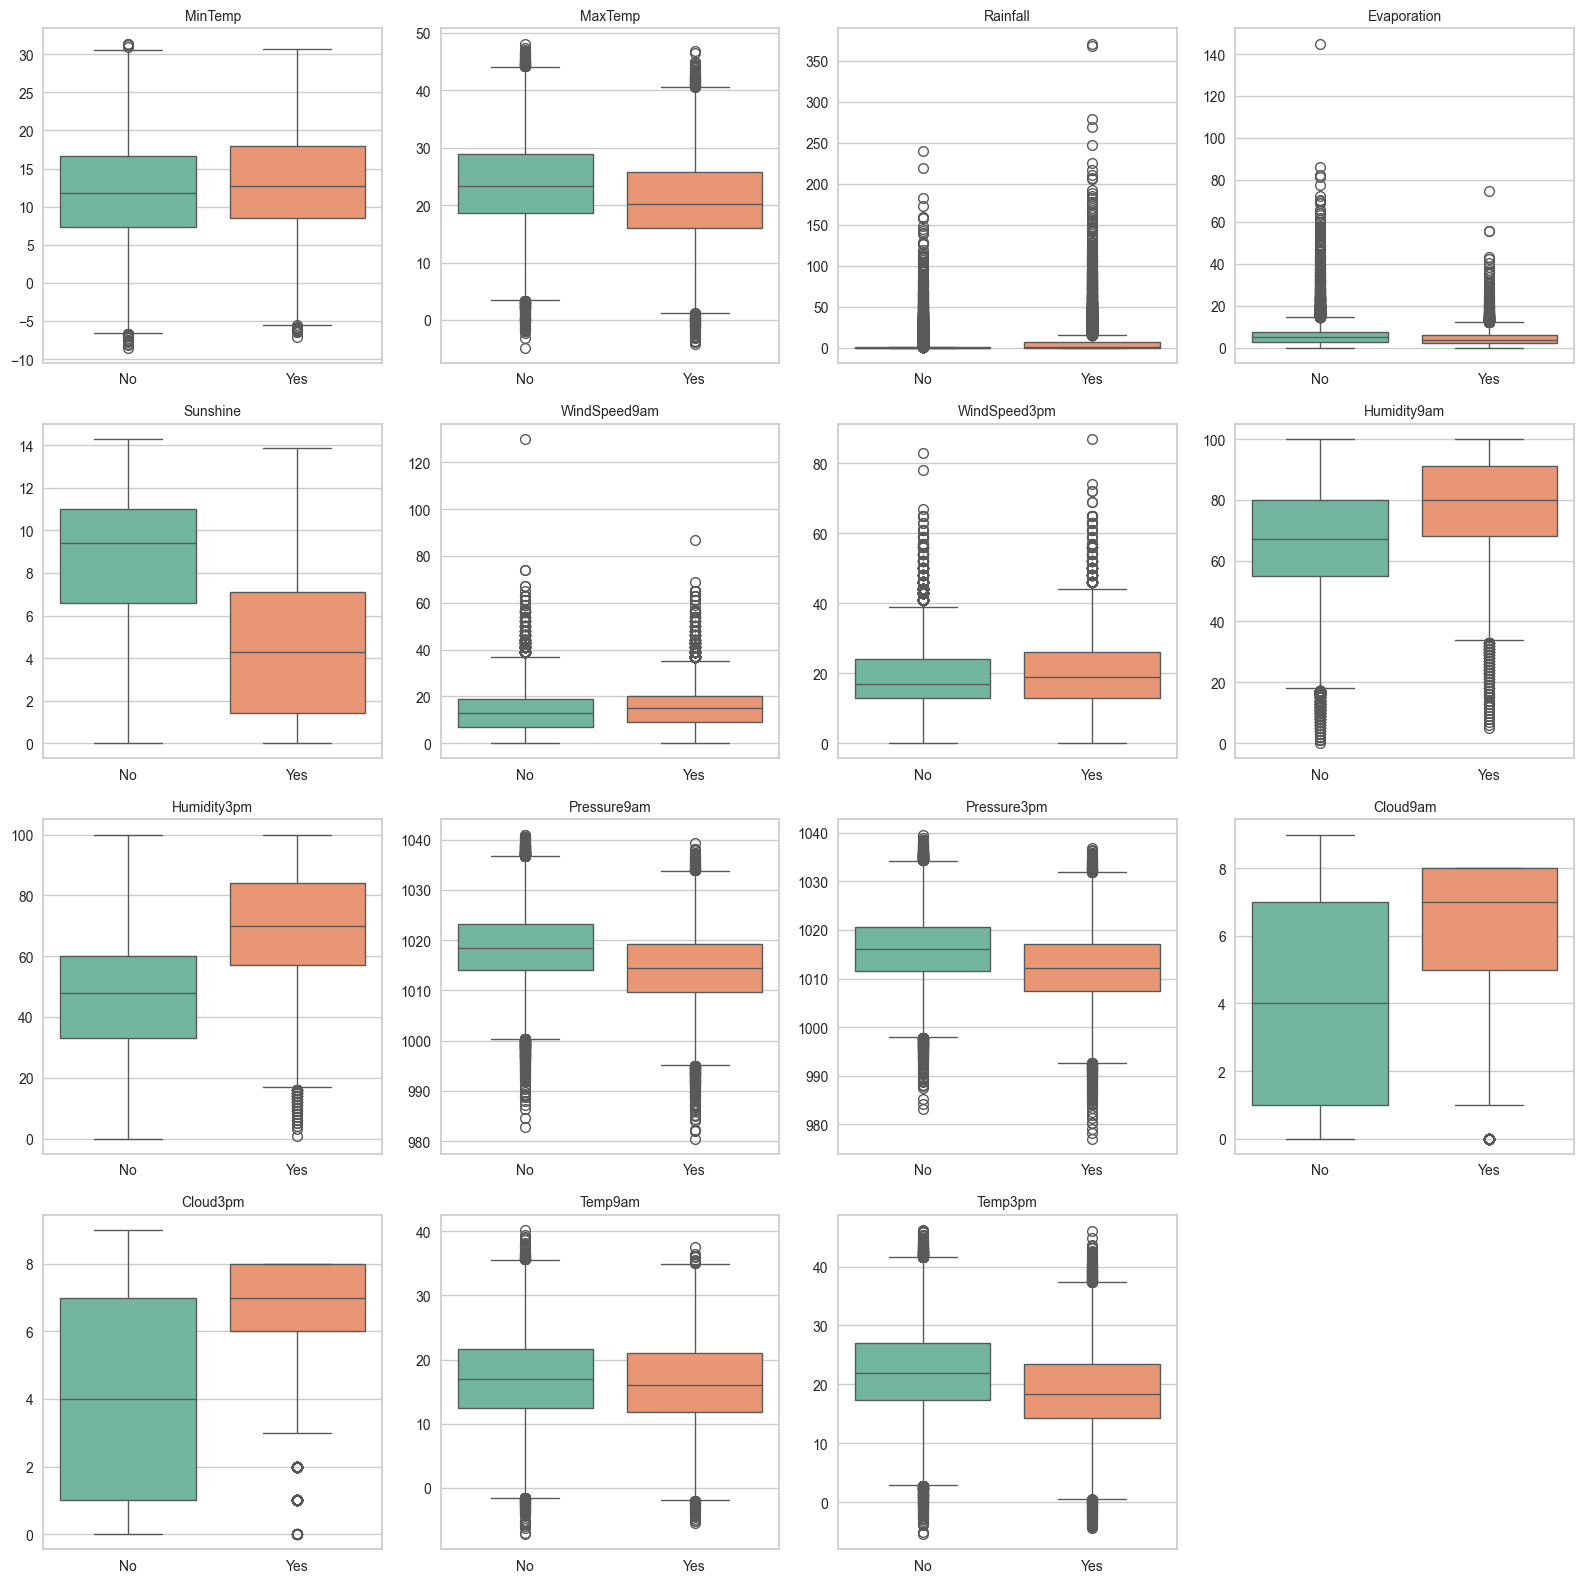

In [14]:
cols = 4
num_vars = len(show.columns) - 1 
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show.columns[:-1]): 
    sns.boxplot(
        data=show,
        x='RainTomorrow',
        y=var, 
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

El conjunto de datos, visualizado a través de los diagramas de caja (boxplots), muestra que la mayoría de las variables, incluyendo Rainfall, Evaporation, Sunshine, y las de Viento y Presión, exhiben una distribución altamente asimétrica y presentan una cantidad significativa de valores atípicos (outliers). Por otro lado, variables como MinTemp, MaxTemp y Humedad tienen distribuciones más simétricas o agrupadas, aunque también contienen atípicos en los extremos.

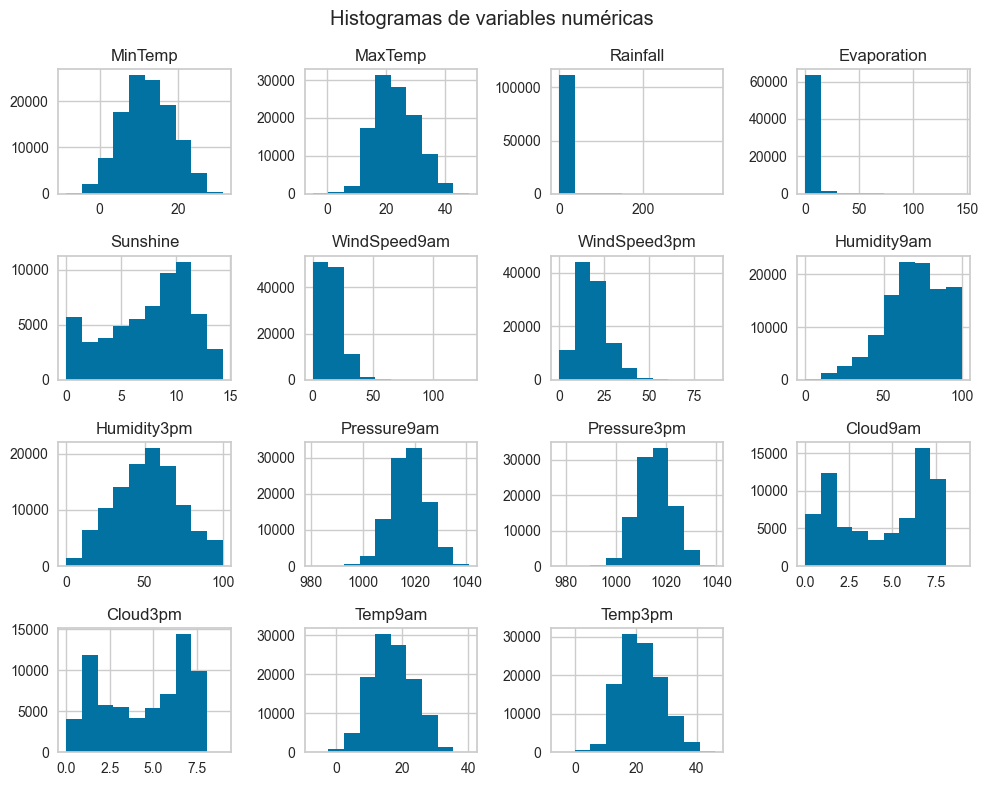

In [15]:
show.hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

Los histogramas confirman una diversidad de formas de distribución entre las variables numéricas. La mayoría de las variables relacionadas con el clima (Rainfall, Evaporation, WindSpeed) muestran una fuerte asimetría positiva (sesgo a la derecha), con valores concentrados cerca de cero, indicando muchos días con poca o nula ocurrencia. En contraste, las variables de Temperatura (MinTemp, MaxTemp, Temp9am, Temp3pm) y Presión presentan distribuciones más cercanas a la normal (o ligeramente sesgadas), mientras que las de Humedad tienden a un sesgo negativo o son más uniformes.

**Análisis y decisión sobre datos faltantes y outliers**

In [16]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

filas_antes_train = len(train)
filas_antes_test = len(test)

Rainfall


In [17]:
#Creamos la columna Rainfall_temp temporal para almacenar la media regional del día
train['Rainfall_temp'] = train.groupby(['Region', 'Date'])['Rainfall'].transform(lambda x: x.fillna(x.mean()))

#Si RainToday = 'No', Rainfall = 0
train.loc[train['RainToday'] == 'No', 'Rainfall'] = train.loc[train['RainToday'] == 'No', 'Rainfall'].fillna(0)

#Si RainToday = 'Yes' o nulo, usar media regional diaria
train.loc[train['Rainfall'].isna() & ((train['RainToday'] == 'Yes') | (train['RainToday'].isna())), 'Rainfall'] = \
    train.loc[train['Rainfall'].isna() & ((train['RainToday'] == 'Yes') | (train['RainToday'].isna())), 'Rainfall_temp']

#Si RainToday = 'Yes' y la media regional diaria = 0 → forzar a 1 mm
train.loc[(train['RainToday'] == 'Yes') & (train['Rainfall'] == 0), 'Rainfall'] = 1

#Eliminamos la columna temporal
train.drop('Rainfall_temp', axis=1, inplace=True)

In [18]:
#Creamos la columna Rainfall_temp temporal para almacenar la media regional del día
test['Rainfall_temp'] = test.groupby(['Region', 'Date'])['Rainfall'].transform(lambda x: x.fillna(x.mean()))

#Si RainToday = 'No', Rainfall = 0
test.loc[test['RainToday'] == 'No', 'Rainfall'] = test.loc[test['RainToday'] == 'No', 'Rainfall'].fillna(0)

#Si RainToday = 'Yes' o nulo, usar media regional diaria
test.loc[test['Rainfall'].isna() & ((test['RainToday'] == 'Yes') | (test['RainToday'].isna())), 'Rainfall'] = \
    test.loc[test['Rainfall'].isna() & ((test['RainToday'] == 'Yes') | (test['RainToday'].isna())), 'Rainfall_temp']

#Si RainToday = 'Yes' y la media regional diaria = 0 → forzar a 1 mm
test.loc[(test['RainToday'] == 'Yes') & (test['Rainfall'] == 0), 'Rainfall'] = 1

#Eliminamos la columna temporal
test.drop('Rainfall_temp', axis=1, inplace=True)

RainToday


In [19]:
#Imputamos RainToday con Rainfall>1mm en el mismo lugar y día
train['RainToday'] = (train['Rainfall'] > 1).map({True: 'Yes', False: 'No'})

#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['Rainfall'].isna().sum(), 'datos')
train = train.dropna(subset=['Rainfall'])

Fueron borrados 0 datos


In [20]:
#Imputamos RainToday con Rainfall>1mm en el mismo lugar y día
test['RainToday'] = (test['Rainfall'] > 1).map({True: 'Yes', False: 'No'})

#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['Rainfall'].isna().sum(), 'datos')
test = test.dropna(subset=['Rainfall'])

Fueron borrados 25 datos


WindGustDir, WindDir9am, WindDir3pm

In [21]:
#Variables Categóricas (WindGustDir, WindDir9am, WindDir3pm) fueron imputadas por moda por región y por date
for col in ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']:
    train[col] = train.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['WindGustSpeed'].isna().sum()+train['WindSpeed9am'].isna().sum()+train['WindSpeed3pm'].isna().sum(), 'datos')
train = train.dropna(subset=['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm'])

Fueron borrados 36 datos


In [22]:
#Variables Categóricas (WindGustDir, WindDir9am, WindDir3pm) fueron imputadas por moda por región y por date
for col in ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']:
    test[col] = test.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['WindGustSpeed'].isna().sum()+test['WindSpeed9am'].isna().sum()+test['WindSpeed3pm'].isna().sum(), 'datos')
test = test.dropna(subset=['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm'])

Fueron borrados 397 datos


Pressure9am, Pressure3pm

In [23]:
#Variables Numéricas - Presión Atmosférica (Pressure9am, Pressure3pm) fueron imputadas según Mediana por Región y Date
for col in ['Pressure9am', 'Pressure3pm']:
    train[col] = train.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['Pressure9am'].isna().sum()+train['Pressure3pm'].isna().sum(), 'datos')
train = train.dropna(subset=['Pressure9am', 'Pressure3pm'])

Fueron borrados 0 datos


In [24]:
#Variables Numéricas - Presión Atmosférica (Pressure9am, Pressure3pm) fueron imputadas según Mediana por Región y Date
for col in ['Pressure9am', 'Pressure3pm']:
    test[col] = test.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['Pressure9am'].isna().sum()+test['Pressure3pm'].isna().sum(), 'datos')
test = test.dropna(subset=['Pressure9am', 'Pressure3pm'])

Fueron borrados 583 datos


MinTemp, MaxTemp, Temp9am, Temp3pm

In [25]:
#Variables Numéricas - Temperaturas (MinTemp, MaxTemp, Temp9am, Temp3pm) fueron imputadas por date y la media de su región

# Imputar con media por Region y Date
for col in ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']:
    train[col] = train.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['MinTemp'].isna().sum()+train['MaxTemp'].isna().sum()+train['Temp9am'].isna().sum()+train['Temp3pm'].isna().sum(), 'datos')
train = train.dropna(subset=['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm'])

Fueron borrados 1 datos


In [26]:
#Variables Numéricas - Temperaturas (MinTemp, MaxTemp, Temp9am, Temp3pm) fueron imputadas por date y la media de su región

# Imputar con media por Region y Date
for col in ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']:
    test[col] = test.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['MinTemp'].isna().sum()+test['MaxTemp'].isna().sum()+test['Temp9am'].isna().sum()+test['Temp3pm'].isna().sum(), 'datos')
test = test.dropna(subset=['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm'])

Fueron borrados 54 datos


Humidity9am, Humidity3pm

In [27]:
#Variables Numéricas - Humedad (Humidity9am, Humidity3pm) imputadas por mediana región y date
for col in ['Humidity9am', 'Humidity3pm']:
    train[col] = train.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )

#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['Humidity9am'].isna().sum()+train['Humidity3pm'].isna().sum(), 'datos')
train = train.dropna(subset=['Humidity9am', 'Humidity3pm'])

Fueron borrados 5 datos


In [28]:
#Variables Numéricas - Humedad (Humidity9am, Humidity3pm) imputadas por mediana región y date
for col in ['Humidity9am', 'Humidity3pm']:
    test[col] = test.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )

#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['Humidity9am'].isna().sum()+test['Humidity3pm'].isna().sum(), 'datos')
test = test.dropna(subset=['Humidity9am', 'Humidity3pm'])

Fueron borrados 48 datos


WindGustSpeed, WindSpeed9am y WindSpeed3pm

In [29]:
#WindGustSpeed, WindSpeed9am y WindSpeed3pm fueron imputadas por mediana en la región
for col in ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']:
    train[col] = train.groupby('Region')[col].transform(
        lambda x: x.fillna(x.median())
    )
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['WindGustSpeed'].isna().sum()+train['WindSpeed9am'].isna().sum()+train['WindSpeed3pm'].isna().sum(), 'datos')
train = train.dropna(subset=['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm'])

Fueron borrados 0 datos


In [30]:
#WindGustSpeed, WindSpeed9am y WindSpeed3pm fueron imputadas por mediana en la región
for col in ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']:
    test[col] = test.groupby('Region')[col].transform(
        lambda x: x.fillna(x.median())
    )
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['WindGustSpeed'].isna().sum()+test['WindSpeed9am'].isna().sum()+test['WindSpeed3pm'].isna().sum(), 'datos')
test = test.dropna(subset=['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm'])

Fueron borrados 0 datos


Cloud9am, Cloud3pm

In [31]:
#Variables Numéricas - Nubosidad (Cloud9am, Cloud3pm) imputadas por mediana de región y date
for col in ['Cloud9am', 'Cloud3pm']:
    train[col] = train.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )

#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['Cloud9am'].isna().sum()+train['Cloud3pm'].isna().sum(), 'datos')
train = train.dropna(subset=['Cloud9am', 'Cloud3pm'])

Fueron borrados 277 datos


In [32]:
#Variables Numéricas - Nubosidad (Cloud9am, Cloud3pm) imputadas por mediana de región y date
for col in ['Cloud9am', 'Cloud3pm']:
    test[col] = test.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.median())
    )

#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['Cloud9am'].isna().sum()+test['Cloud3pm'].isna().sum(), 'datos')
test = test.dropna(subset=['Cloud9am', 'Cloud3pm'])

Fueron borrados 4105 datos


Evaporation

In [33]:
#Variable Numérica - Evaporación (Evaporation) fue imputada por la Mediana por región y date
train['Evaporation'] = train.groupby(['Region', 'Date'])['Evaporation'].transform(
    lambda x: x.fillna(x.median())
)
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['Evaporation'].isna().sum(), 'datos')
train = train.dropna(subset=['Evaporation'])

Fueron borrados 85 datos


In [34]:
#Variable Numérica - Evaporación (Evaporation) fue imputada por la Mediana por región y date
test['Evaporation'] = test.groupby(['Region', 'Date'])['Evaporation'].transform(
    lambda x: x.fillna(x.median())
)
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['Evaporation'].isna().sum(), 'datos')
test = test.dropna(subset=['Evaporation'])

Fueron borrados 1113 datos


Direcciones de Viento (WindGustDir, WindDir9am, WindDir3pm)

In [35]:
#Variables Categóricas - Direcciones de Viento (WindGustDir, WindDir9am, WindDir3pm) fueron imputadas por Moda por región y date
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    train[col] = train.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])
    )
    
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['WindGustDir'].isna().sum()+train['WindDir9am'].isna().sum()+train['WindDir3pm'].isna().sum(), 'datos')
train = train.dropna(subset=['WindGustDir', 'WindDir9am', 'WindDir3pm'])

Fueron borrados 18 datos


In [36]:
#Variables Categóricas - Direcciones de Viento (WindGustDir, WindDir9am, WindDir3pm) fueron imputadas por Moda por región y date
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    test[col] = test.groupby(['Region', 'Date'])[col].transform(
        lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])
    )
    
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['WindGustDir'].isna().sum()+test['WindDir9am'].isna().sum()+test['WindDir3pm'].isna().sum(), 'datos')
test = test.dropna(subset=['WindGustDir', 'WindDir9am', 'WindDir3pm'])

Fueron borrados 71 datos


Sunshine

In [37]:
#Variables Numéricas - Duración de Sol (Sunshine) fue imputada por la Mediana por región y date
train['Sunshine'] = train.groupby(['Region', 'Date'])['Sunshine'].transform(
    lambda x: x.fillna(x.median())
)
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', train['Sunshine'].isna().sum(), 'datos')
train = train.dropna(subset=['Sunshine'])

Fueron borrados 280 datos


In [38]:
#Variables Numéricas - Duración de Sol (Sunshine) fue imputada por la Mediana por región y date
test['Sunshine'] = test.groupby(['Region', 'Date'])['Sunshine'].transform(
    lambda x: x.fillna(x.median())
)
#Los datos que no pudieron ser imputados, son borrados
print('Fueron borrados', test['Sunshine'].isna().sum(), 'datos')
test = test.dropna(subset=['Sunshine'])

Fueron borrados 708 datos


Total

In [39]:
print(train.isnull().sum())
print(test.isnull().sum())

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Latitude         0
Longitude        0
Region           0
RainTomorrow     0
dtype: int64
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Latitude         0
Longitude        0
Region           0
RainTomorrow     0

In [40]:
filas_despues_train = len(train)
print('Cantidad total de filas eliminadas de train: ', filas_antes_train - filas_despues_train)

filas_despues_test = len(test)
print('Cantidad total de filas eliminadas de test: ', filas_antes_test - filas_despues_test)

Cantidad total de filas eliminadas de train:  633
Cantidad total de filas eliminadas de test:  5084


**División y elección de variables importantes**

In [41]:
# reconstruir X,y desde train/test (post-imputaciones)
X_train = train.drop(columns=['RainTomorrow']).reset_index(drop=True)
X_test  = test.drop(columns=['RainTomorrow']).reset_index(drop=True)
y_train = train['RainTomorrow'].reset_index(drop=True)
y_test  = test['RainTomorrow'].reset_index(drop=True)

cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir',
        'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm',
        'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
        'Temp9am', 'Temp3pm', 'RainToday', 'Region']

X_train = X_train[cols]
X_test  = X_test[cols]

**Codificación de variables categóricas**

In [42]:
X_train['RainToday'] = X_train['RainToday'].map({'No': 0, 'Yes': 1})
X_test['RainToday']  = X_test['RainToday'].map({'No': 0, 'Yes': 1})

In [43]:
y_train = y_train.map({'No':0, 'Yes':1})
y_test  = y_test.map({'No':0, 'Yes':1})

In [44]:
X_all = pd.concat([X_train, X_test], axis=0)
X_all = pd.get_dummies(X_all, drop_first=True)

X_train = X_all.iloc[:len(X_train), :].reset_index(drop=True)
X_test  = X_all.iloc[len(X_train): , :].reset_index(drop=True)

**Visualización de datos** (posterior a la imputación)

In [45]:
show = X_train[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
                'Temp3pm']].copy()

show['RainTomorrow'] = y_train.values

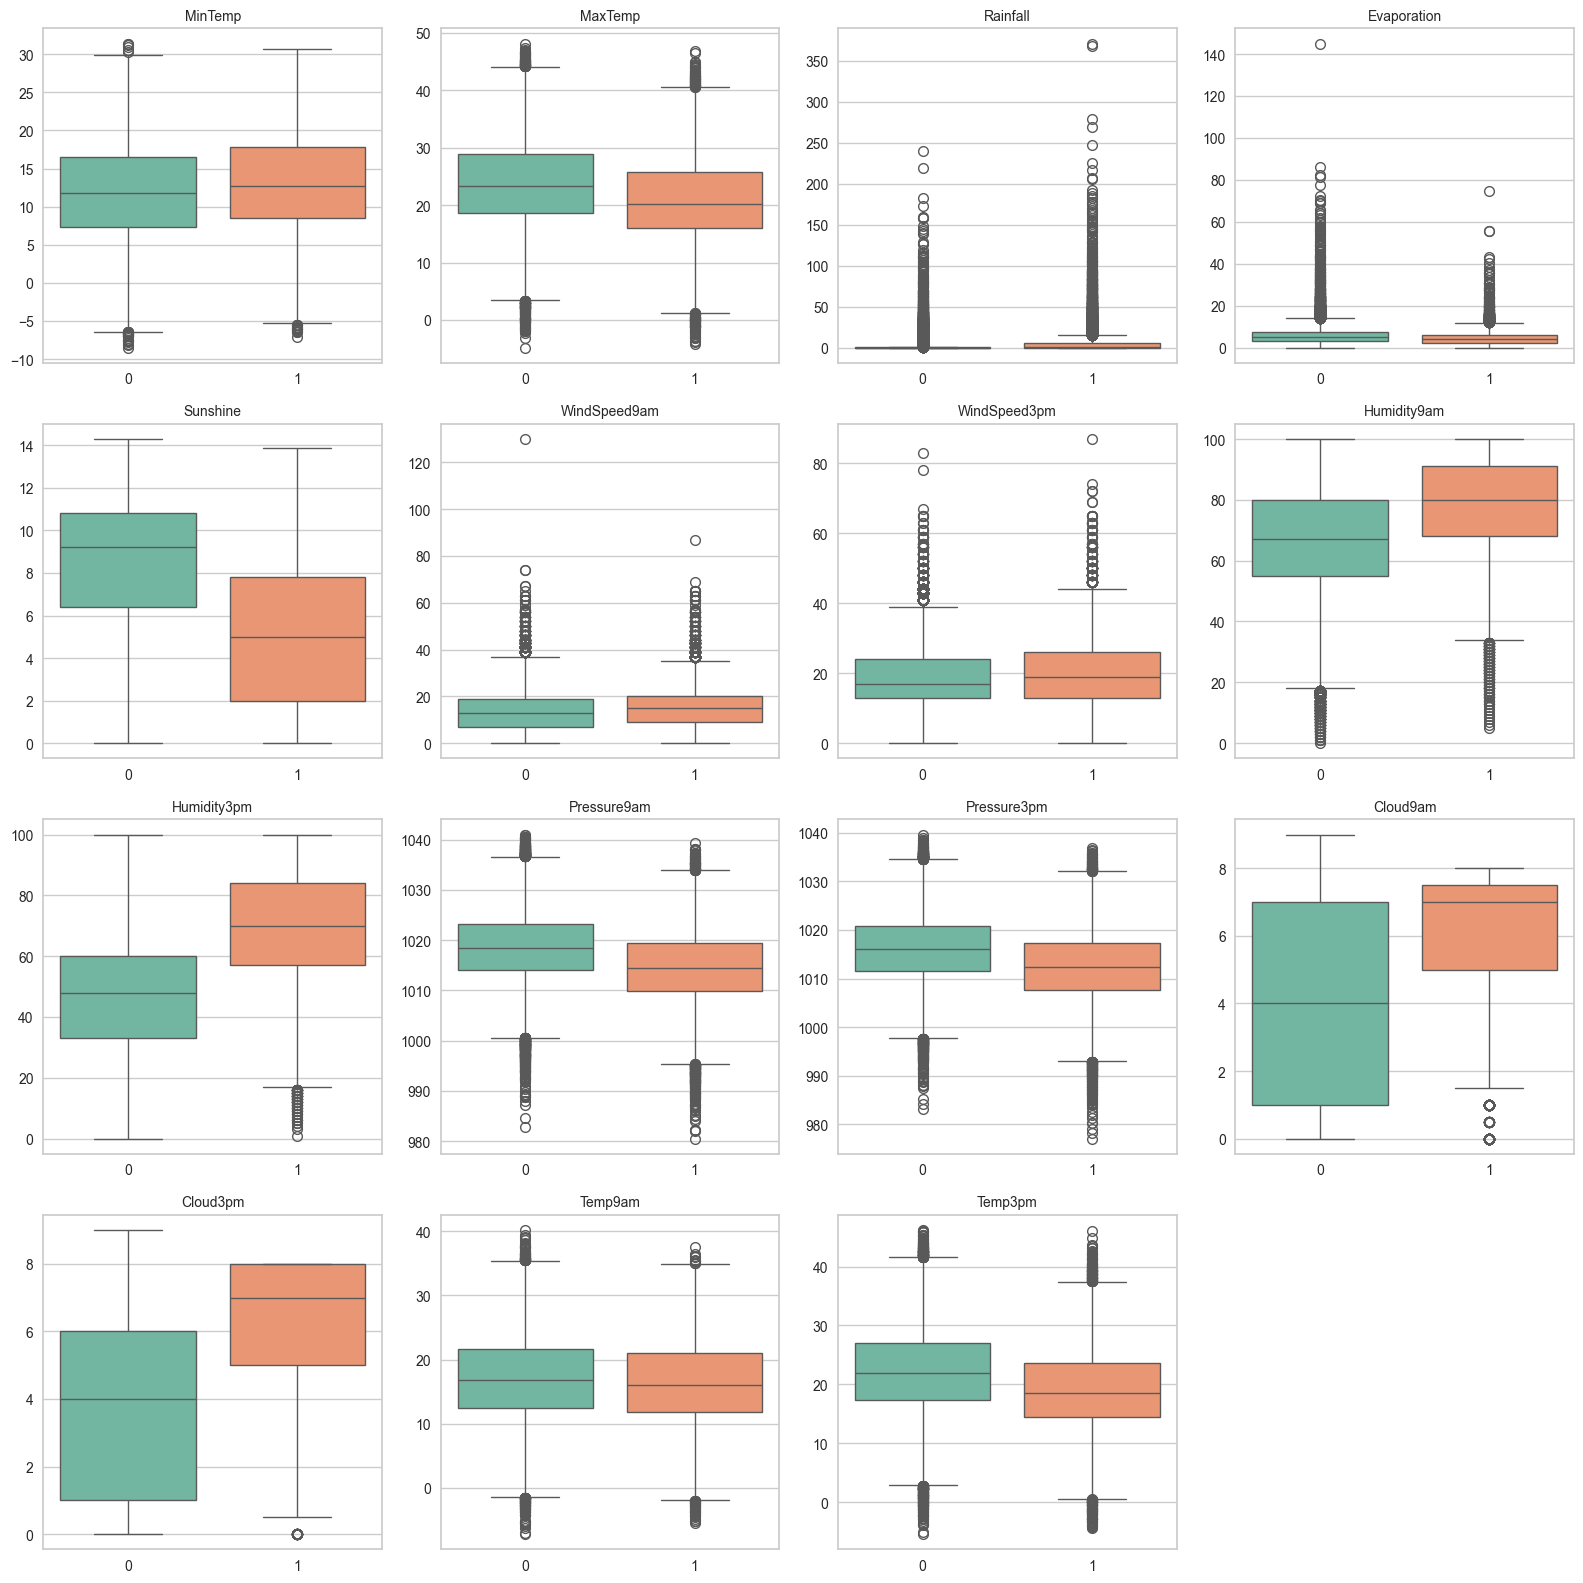

In [46]:
# cols = 4
# num_vars = len(show.columns)
# rows = (num_vars + cols - 1) // cols

# fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
# axes = axes.flatten()

# for i, var in enumerate(show.columns):
#     sns.boxplot(data=show, x=var, ax=axes[i], color='skyblue')
#     axes[i].set_title(f'{var}', fontsize=10)
#     axes[i].set_xlabel('')
#     axes[i].set_ylabel('')

# for j in range(i+1, len(axes)):
#     axes[j].set_visible(False)

# plt.tight_layout()
# plt.show()

cols = 4
num_vars = len(show.columns) - 1
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show.columns[:-1]): 
    sns.boxplot(
        data=show,
        x='RainTomorrow', 
        y=var,
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Ocultar ejes vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

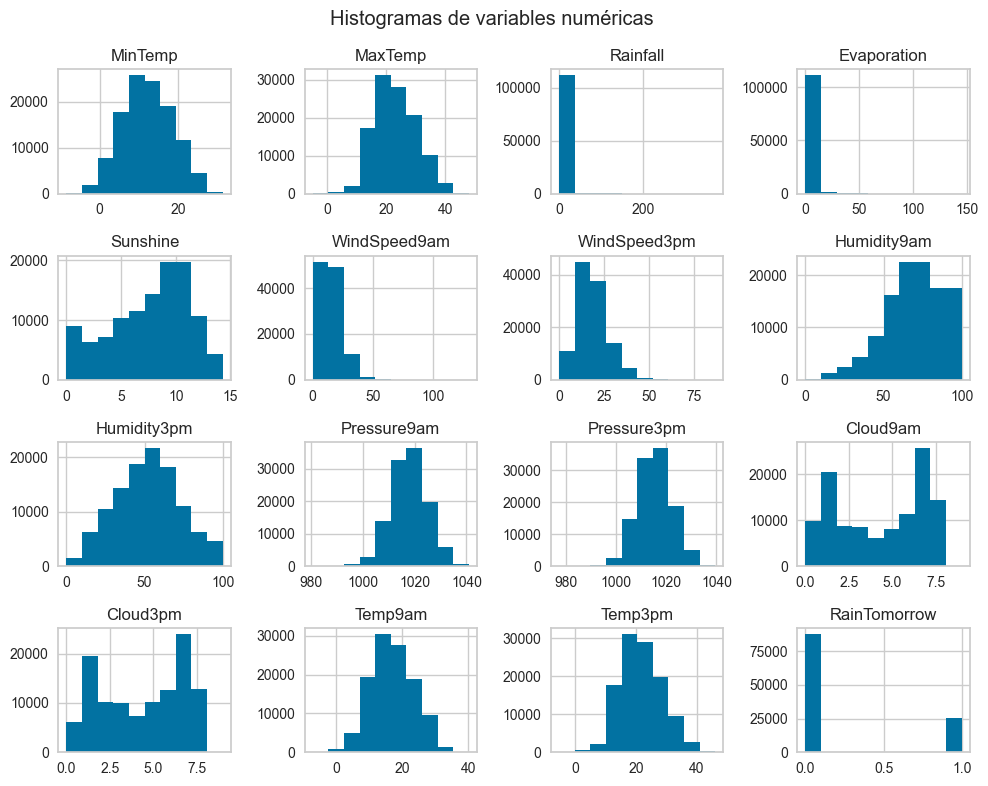

In [47]:
show.hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

Tras la imputación de valores faltantes, las distribuciones se mantienen prácticamente iguales a las visualizadas en los gráficos anteriores, tanto en su forma como en sus medidas de tendencia y dispersión. Esto sugiere que el método de imputación preservó la estructura original de los datos sin introducir sesgos.

In [48]:
# pshow = show.copy()
# pshow['RainTomorrow'] = y_train

# sns.pairplot(pshow.sample(1000, random_state=1), hue='RainTomorrow', diag_kind='kde', plot_kws={'alpha': 0.5})
# plt.title('Scatterplot entre variables')
# plt.show()

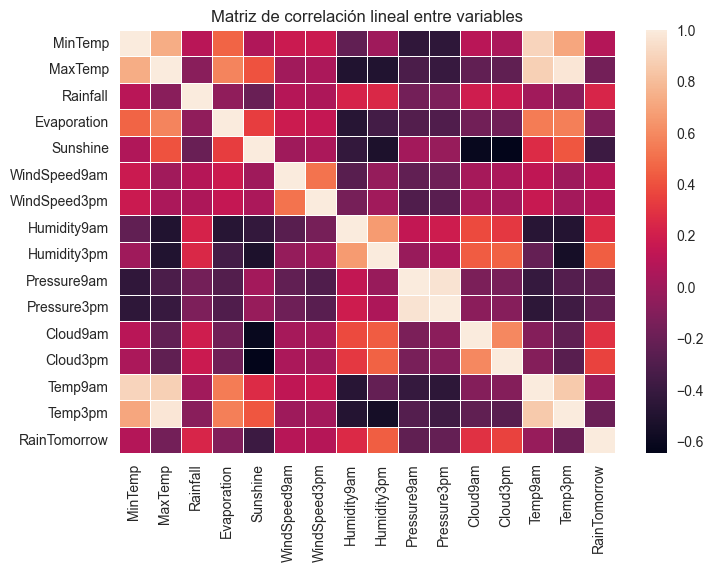

In [49]:
corrmat = show.corr()

sns.heatmap(corrmat, vmax=1, linewidths=.5)
plt.title('Matriz de correlación lineal entre variables')
plt.show()

La matriz de correlación lineal muestra relaciones significativas entre distintas variables meteorológicas:

1. Temperaturas
- Existe una correlación positiva muy fuerte entre MinTemp y MaxTemp, así como entre Temp9am y Temp3pm, lo que indica coherencia en las mediciones: los días más cálidos en la mañana tienden a mantener temperaturas altas en la tarde.
- Estas relaciones reflejan la estabilidad térmica diaria y sugieren que la temperatura matutina puede servir como un buen predictor de la temperatura vespertina.

2. Presión atmosférica y temperatura
- Se observa una correlación negativa moderada a fuerte entre la presión (Pressure9am/3pm) y las temperaturas (Temp9am/3pm).
- Este patrón es consistente con la física atmosférica: una presión baja suele asociarse a aire cálido y húmedo, mientras que la alta presión se asocia a aire más frío y seco.

3. Nubosidad y horas de sol
- Sunshine muestra una correlación negativa fuerte con Cloud9am y Cloud3pm, lo cual es esperable: a mayor nubosidad, menos horas de sol se registran.
- Esto refleja una consistencia interna en los datos y una posible variable redundante (una de las dos podría omitirse en modelos predictivos).

4. Humedad y lluvia
- Rainfall tiene correlaciones positivas débiles con Humidity9am/3pm y con Cloud9am/3pm, lo que sugiere que, aunque la humedad y la nubosidad se asocian a lluvias, la relación no es perfectamente lineal.
- Esto puede deberse a la naturaleza no lineal de los fenómenos de precipitación: la lluvia depende de múltiples factores simultáneos (presión, temperatura, viento, etc.).

5. Otras observaciones
- Las correlaciones entre las velocidades del viento (WindSpeed9am y WindSpeed3pm) son moderadas, indicando cierta continuidad durante el día.
- Variables como Evaporation y Sunshine presentan una correlación positiva, coherente con el hecho de que mayor radiación solar favorece la evaporación.

En conclusión, la matriz permite evidenciar relaciones coherentes y útiles para la modelización meteorológica. Las temperaturas, presiones y nubosidad muestran los patrones esperados, lo cual valida la calidad de los datos. Además, permite identificar variables redundantes o dependientes (como Cloud y Sunshine) y potenciales predictores clave (Temp9am, Pressure3pm, Humidity3pm) para la predicción de lluvia o de otras condiciones climáticas.

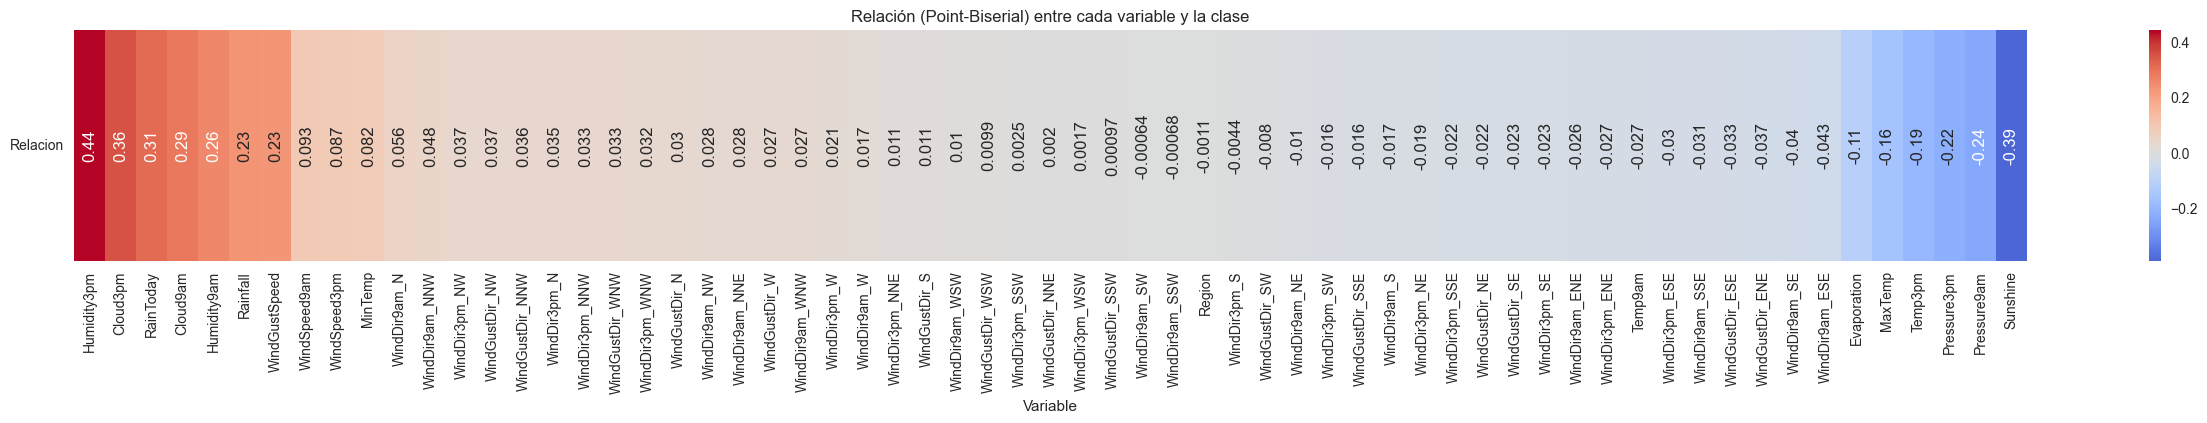

In [50]:
def relacion(X_train, y_train):
    resultados = []

    for col in X_train.columns:
        corr, _ = pointbiserialr(X_train[col], y_train)
        resultados.append({'Variable': col, 'Relacion': corr})
    
    return pd.DataFrame(resultados).sort_values(by='Relacion', ascending=False)

df_corr = relacion(X_train, y_train)
df_corr = df_corr.set_index("Variable")

plt.figure(figsize=(len(df_corr)*0.5, 3))
sns.heatmap(
    df_corr[["Relacion"]].T,
    annot=True,
    cmap="coolwarm",
    center=0,
    annot_kws={"rotation": 90, "va": "center", "ha": "center"}
)
plt.title("Relación (Point-Biserial) entre cada variable y la clase")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

En el gráfico se evidencian algunas variables que presentan una relación moderada con la variable objetivo, mientras que la mayoría posee una influencia débil. Entre las variables con mayor correlación positiva destacan Humidity3pm (0.44), Cloud3pm (0.36) y RainToday (0.31), indicando que condiciones de mayor humedad y nubosidad por la tarde, así como la presencia de lluvia previa, se asocian con una mayor probabilidad de la clase positiva. En menor medida, también aportan Cloud9am y Humidity9am.

Por otro lado, las correlaciones negativas más relevantes se observan en Sunshine (-0.39), Pressure9am (-0.24) y Pressure3pm (-0.22), sugiriendo que mayor cantidad de horas de sol y mayor presión atmosférica tienden a asociarse con la clase negativa.

**Estandarización/escalado de datos.**

In [51]:
# Estandarizar todas las columnas (ya son todas numéricas)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Análisis del balance de clases**

In [52]:
train_counts = y_train.value_counts().rename("Cantidad_train")
train_perc = (y_train.value_counts(normalize=True) * 100).round(2).rename("Porcentaje_train")

test_counts = y_test.value_counts().rename("Cantidad_test")
test_perc = (y_test.value_counts(normalize=True) * 100).round(2).rename("Porcentaje_test")

tabla_balance = pd.concat([train_counts, train_perc, test_counts, test_perc], axis=1)
tabla_balance.index.name = "Clase"
display(tabla_balance)

,Cantidad_train,Porcentaje_train,Cantidad_test,Porcentaje_test
Clase,,,,
0,87769,77.59,18142,77.68
1,25352,22.41,5213,22.32


El conjunto de datos presenta un desbalance marcado entre clases (≈78% vs 22%), aunque la partición en entrenamiento y prueba mantiene correctamente esta proporción sin introducir sesgos adicionales.

## Red neuronal

In [100]:
class NeuralNetwork:
    def __init__(self, epochs=50, batch_size=32, learning_rate=0.001, hidden_layers=[64, 32], dropout_rate=0.0):
        
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.hidden_layers = hidden_layers
        self.dropout_rate = dropout_rate
        
        self.model = None
        self.history = None

        self.X_train = None
        self.y_train = None
        self.X_valid = None
        self.y_valid = None
        self.X_test = None
        self.y_test = None
        
        self.pred_classes = None
        self.pred_probs = None


    def build_model(self, input_shape, num_classes):
        model = tf.keras.models.Sequential()
        model.add(tf.keras.layers.InputLayer(input_shape=(input_shape,)))

        for neurons in self.hidden_layers:
            model.add(tf.keras.layers.Dense(neurons, activation='relu'))
            if self.dropout_rate > 0:
                model.add(tf.keras.layers.Dropout(self.dropout_rate))
                
        # Capa de salida
        model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer,
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        self.model = model


    def train(self, X_train, y_train, X_valid, y_valid, callbacks=None):
        self.X_train = X_train
        self.y_train = y_train
        self.X_valid = X_valid
        self.y_valid = y_valid

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=0,
            callbacks=callbacks
        )
        return self.history.history


    def predict(self, X_new):
        pred_probs = self.model.predict(X_new)
        pred_classes = np.argmax(pred_probs, axis=1)

        self.pred_classes = pred_classes
        self.pred_probs = pred_probs
        return pred_classes, pred_probs


    ## Métricas

    def evaluate(self, X_test, y_test):
        """Evalúa el modelo en el conjunto de test"""
        self.X_test = X_test
        self.y_test = y_test
        
        loss, accuracy = self.model.evaluate(X_test, y_test)

        y_pred_probs = self.model.predict(X_test)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        self.pred_classes = y_pred
        self.pred_probs = y_pred_probs

        y_true = np.argmax(y_test, axis=1)

        f1 = f1_score(y_true, y_pred, average='weighted')

        print(f"Test accuracy: {accuracy:.4f}")
        print(f"Test f1: {f1:.4f}")
        return accuracy, f1
    

    def plot_loss(self):
        if self.history is None:
            print("Error: No hay history. Entrená primero el modelo.")
            return
        
        plt.figure(figsize=(8,5))
        plt.plot(self.history.history['loss'], label='Train Loss')
        plt.plot(self.history.history['val_loss'], label='Test Loss')
        plt.title("Evolución de la función de pérdida")
        plt.xlabel("Épocas")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid()
        plt.show()


    def plot_confusion_matrix(self, labels=None):
        if self.pred_classes is None or self.y_test is None:
            print("Error: No hay predicciones. Llamá primero a evaluate().")
            return
        
        y_true = np.argmax(self.y_test, axis=1)
        
        cm = confusion_matrix(y_true, self.pred_classes)

        plt.figure(figsize=(6,5))
        if labels is not None:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=labels, yticklabels=labels)
        else:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("Matriz de Confusión")
        plt.xlabel("Predicción")
        plt.ylabel("Real")
        plt.show()


    def classification_metrics(self):
        if self.pred_classes is None or self.y_test is None:
            print("Error: No hay predicciones. Llamá primero a evaluate().")
            return
        
        y_true = np.argmax(self.y_test, axis=1)
        
        print("Reporte de Clasificación:")
        print(classification_report(y_true, self.pred_classes))


    ## Curva ROC
    def roc_curve(self):
        if self.pred_probs is None or self.y_test is None:
            print("Error: llamá primero a evaluate().")
            return

        y_true = np.argmax(self.y_test, axis=1)

        # probabilidad de la clase positiva
        y_score = self.pred_probs[:, 1]

        # Curva ROC
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc_value = auc(fpr, tpr)

        # Índice de Youden para umbral óptimo
        youden_index = tpr - fpr
        optimal_threshold = thresholds[np.argmax(youden_index)]

        print(f"Umbral óptimo: {optimal_threshold:.4f}")
        print(f"ROC AUC Score: {roc_auc_value:.4f}")

        y_pred_opt = (y_score >= optimal_threshold).astype(int)
        self.pred_classes = y_pred_opt

        # Gráfico
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'Curva ROC (AUC = {roc_auc_value:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Tasa de Falsos Positivos (FPR)')
        plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
        plt.title('Curva ROC')
        plt.legend(loc="lower right")
        plt.grid()
        plt.show()

        return roc_auc_value

In [101]:
num_classes = len(np.unique(y_train))

y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

In [102]:
X_train_nn, X_val, y_train_nn, y_val = train_test_split(
    X_train_scaled, y_train_encoded, test_size=0.2, random_state=42
)

**Optimización de hiperparámetros**

In [103]:
warnings.filterwarnings('ignore')

def objective(trial):
    nn = NeuralNetwork(
        epochs=trial.suggest_int('epochs', 20, 50),
        batch_size=trial.suggest_categorical('batch_size', [32, 64]),
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        hidden_layers=[
            trial.suggest_int('layer1', 32, 64),
            trial.suggest_int('layer2', 16, 32)
        ],
        dropout_rate=trial.suggest_float('dropout_rate', 0.1, 0.5)
    )
    
    nn.build_model(X_train_scaled.shape[1], num_classes)
    
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
    nn.train(X_train_nn, y_train_nn, X_val, y_val, callbacks=[early_stop])
    
    accuracy, f1 = nn.evaluate(X_test_scaled, y_test_encoded)
    return f1

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f"Mejores parámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"\nMejor F1 Score: {study.best_value:.4f}")
print("="*50)

  0%|          | 0/10 [00:00<?, ?it/s]

730/730 [==============================] - 1s 736us/step
Test accuracy: 0.8525
Test f1: 0.8412
730/730 [==============================] - 1s 775us/step
Test accuracy: 0.8541
Test f1: 0.8431
730/730 [==============================] - 1s 796us/step
Test accuracy: 0.8534
Test f1: 0.8424
730/730 [==============================] - 1s 778us/step
Test accuracy: 0.8493
Test f1: 0.8349
730/730 [==============================] - 1s 842us/step
Test accuracy: 0.8542
Test f1: 0.8471
730/730 [==============================] - 1s 1ms/step
Test accuracy: 0.8533
Test f1: 0.8411
730/730 [==============================] - 1s 1ms/step
Test accuracy: 0.8538
Test f1: 0.8429
730/730 [==============================] - 1s 1ms/step
Test accuracy: 0.8548
Test f1: 0.8448
730/730 [==============================] - 1s 1ms/step
Test accuracy: 0.8539
Test f1: 0.8433
730/730 [==============================] - 1s 1ms/step
Test accuracy: 0.8528
Test f1: 0.8425
Mejores parámetros encontrados:
  epochs: 39
  batch_size: 3

**Mejor modelo**

In [104]:
best_params = study.best_params

In [105]:
warnings.filterwarnings('ignore')

nn = NeuralNetwork(
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate'],
    hidden_layers=[best_params['layer1'], best_params['layer2']],
    dropout_rate=best_params['dropout_rate']
)

nn.build_model(X_train_scaled.shape[1], num_classes)

early_stop_nn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

nn.train(X_train_nn, y_train_nn, X_val, y_val, callbacks=[early_stop_nn])

y_pred_nn, y_proba_nn = nn.predict(X_test_scaled)

print("\nEvaluación final del modelo optimizado:")
accuracy_nn, f1_nn = nn.evaluate(X_test_scaled, y_test_encoded)

730/730 [==============================] - 1s 1ms/step

Evaluación final del modelo optimizado:
730/730 [==============================] - 1s 1ms/step
Test accuracy: 0.8513
Test f1: 0.8407


**Curva ROC**

Umbral óptimo: 0.2494
ROC AUC Score: 0.8832


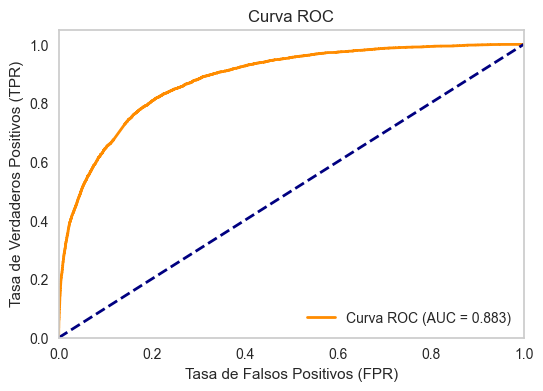

In [106]:
roc_auc_nn = nn.roc_curve()

**Métricas**

In [107]:
nn.classification_metrics()

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     18142
           1       0.53      0.82      0.64      5213

    accuracy                           0.80     23355
   macro avg       0.73      0.80      0.75     23355
weighted avg       0.85      0.80      0.81     23355



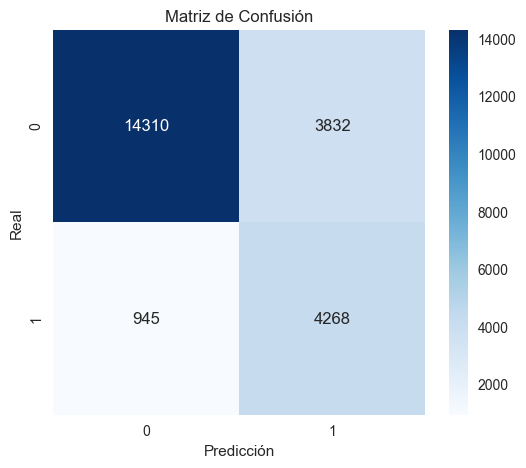

In [108]:
nn.plot_confusion_matrix()

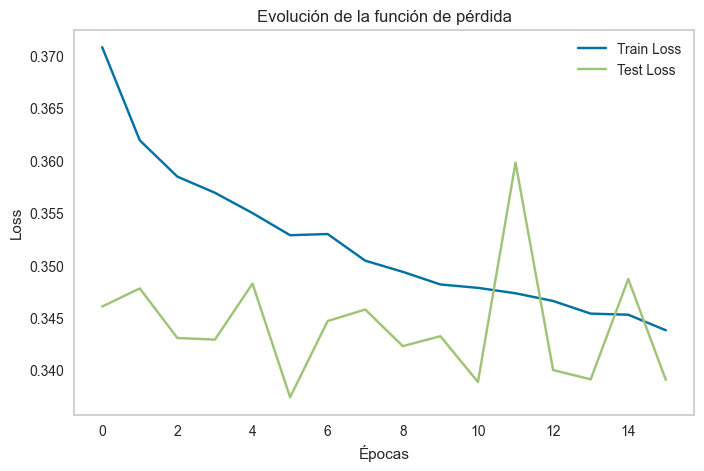

In [109]:
nn.plot_loss()